In [ ]:
# Install required packages once (run in terminal, not notebook):
# pip install pandas numpy matplotlib pillow beautifulsoup4 requests gitpython
!{sys.executable} -m pip install requests pillow beautifulsoup4 seaborn
!{sys.executable} -m pip install pandas==1.5.3
!{sys.executable} -m pip install numpy==1.23.5
!{sys.executable} -m pip install matplotlib==3.7.3

In [ ]:
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# Example Data

In [ ]:
# git clone https://github.com/SoftwareImpacts/SIMPAC-2022-305.git
# file_path = Path('content/SIMPAC-2022-305/DEMO/demo_data.txt')
file_path = Path("data/demo_data.txt")

#GazeParser

In [ ]:
# GazeParser

# 1. Install dependencies that work easily in Colab
# pip install numpy scipy matplotlib pillow

# 2. Install GazeParser without its "dependencies" (bypassing wxPython)
# pip install GazeParser --no-deps

# 3. Verify the installation
import GazeParser
print(f"GazeParser version {GazeParser.__version__} is ready!")

In [ ]:
# TODO This seems not using GazeParser

"""
Methodologically, what matters is:
 - the fixation definition (I-DT vs I-VT)
 - the thresholds
 - the validation
"""


# -------------------------------
# PARAMETERS (peyemmv-like)
# -------------------------------
DISPERSION_THRESHOLD = 0.25   # spatial dispersion (normalized units)
MIN_DURATION_MS = 150         # minimum fixation duration

# -------------------------------
# Load raw gaze data (robust)
# -------------------------------
rows = []
with open(file_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < 3:
            continue
        try:
            x = float(parts[0])
            y = float(parts[1])
            t = float(parts[2])
            rows.append((t, x, y))
        except ValueError:
            pass

df = pd.DataFrame(rows, columns=["time", "x", "y"])
df = df.sort_values("time").reset_index(drop=True)

# -------------------------------
# I-DT Fixation Detection
# -------------------------------
fixations = []
start_idx = 0

while start_idx < len(df):
    end_idx = start_idx + 1

    while end_idx < len(df):
        window = df.iloc[start_idx:end_idx+1]
        dispersion = (
            (window["x"].max() - window["x"].min()) +
            (window["y"].max() - window["y"].min())
        )

        duration = window["time"].iloc[-1] - window["time"].iloc[0]

        if dispersion > DISPERSION_THRESHOLD:
            break

        end_idx += 1

    window = df.iloc[start_idx:end_idx]
    duration = window["time"].iloc[-1] - window["time"].iloc[0]

    if duration >= MIN_DURATION_MS:
        fixations.append({
            "start_time_ms": window["time"].iloc[0],
            "end_time_ms": window["time"].iloc[-1],
            "duration_ms": duration,
            "x": window["x"].mean(),
            "y": window["y"].mean()
        })

    start_idx = end_idx

fix_df = pd.DataFrame(fixations)
print(len(fix_df))
display(fix_df.head())


In [ ]:
def plot_gazeparser_fixations(pts, fix_df, title="GazeParser Fixations"):
    fig, ax = plt.subplots()
    ax.set_title(f"{title} | Fixations: {len(fix_df)}")
    ax.set_xlabel("Horizontal coordinates (tracker units)")
    ax.set_ylabel("Vertical coordinates (tracker units)")

    # Raw gaze
    ax.scatter(pts[:, 0], pts[:, 1],
               color='blue', marker='+', alpha=0.6, label='raw gaze')

    if len(fix_df) == 0:
        return

    # Fixation centers
    ax.scatter(fix_df["x"], fix_df["y"],
               color='red', marker='o', label='fixations')

    # Annotate durations
    for _, r in fix_df.iterrows():
        ax.text(r["x"], r["y"],
                f"{r['duration_ms']:.0f}",
                color='red', fontsize=9)

        ax.legend(['raw gaze data','fixation centers and their durations'],loc='best')
    plt.show()

    if len(fix_df) > 0:
        print(f"--- Fixations ({len(fix_df)}) ---")
        for i, r in enumerate(fix_df.itertuples(), 1):
            print(
                f"{i}. x={r.x:.3f}, y={r.y:.3f}, "
                f"{r.duration_ms:.0f}ms "
                f"[{r.start_time_ms:.0f}–{r.end_time_ms:.0f}]"
            )
    else:
        print("--- No fixations ---")


pts = np.genfromtxt(file_path, usecols=(0, 1, 2), invalid_raise=False)
pts = pts[~np.isnan(pts).any(axis=1)]
plot_gazeparser_fixations(pts, fix_df)


In [ ]:
# TODO DB CREATION DOES NOT WORK

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import GazeParser
import GazeParser.Converter as GPconv
import glob
import os

# --------------------------------------------------
# Step 1: Generate dummy gaze data (pixels, ms)
# --------------------------------------------------
np.random.seed(0)

n = 1500
time = np.arange(n) * 10.0  # 100 Hz

# Two fixations with a saccade
x = np.concatenate([
    np.random.normal(400, 5, 500),
    np.linspace(400, 800, 50),
    np.random.normal(800, 5, 950)
])

y = np.concatenate([
    np.random.normal(300, 5, 500),
    np.linspace(300, 600, 50),
    np.random.normal(600, 5, 950)
])

# --------------------------------------------------
# Step 2: Build SimpleGazeTracker-style CSV
# --------------------------------------------------
df = pd.DataFrame({
    "Time": time,
    "Lx": x,
    "Ly": y,
    "Rx": x,
    "Ry": y,
    "LPupil": np.ones(n) * 3.0,
    "RPupil": np.ones(n) * 3.0,
    "Event": np.zeros(n, dtype=int)
})

csv_file = "simplegazetracker_dummy.csv"
df.to_csv(csv_file, index=False)

print("CSV written:", csv_file)

# --------------------------------------------------
# Step 3: Convert CSV → GazeParser DB
# --------------------------------------------------
GPconv.TrackerToGazeParser(csv_file, overwrite=True)

# Find DB
db_files = glob.glob("**/*.db", recursive=True)
assert db_files, "No DB created"
db_file = db_files[0]

print("DB file:", db_file)

# --------------------------------------------------
# Step 4: Load DB and extract fixations
# --------------------------------------------------
gazedata_list, _ = GazeParser.load(db_file)
gdata = gazedata_list[0]

print("Fixations detected:", gdata.nFix)

fixations = []
for i in range(gdata.nFix):
    start, end = gdata.getFixTime(i)
    dur = gdata.getFixDur(i)
    cx, cy = gdata.getFixCenter(i)

    fixations.append((cx, cy, dur, start, end))

fix_df = pd.DataFrame(
    fixations,
    columns=["x", "y", "duration_ms", "start_ms", "end_ms"]
)

# --------------------------------------------------
# Step 5: Plot raw gaze + GazeParser fixations
# --------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=5, alpha=0.4, label="Raw gaze")
plt.scatter(
    fix_df["x"], fix_df["y"],
    c="red", s=80, label="Fixations"
)

for _, r in fix_df.iterrows():
    plt.text(r.x, r.y, f"{r.duration_ms:.0f} ms",
             color="red", fontsize=9)

plt.gca().invert_yaxis()
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("GazeParser Fixation Analysis (Dummy Data)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Conclusion

This library seems working only on data generated by GazeTracker. However, the algorithm (the fixation definition I-DT vs I-VT) might worth for further investigation.

I have not found example file for eye tracking data for trying this tool. However, relevant links:

* [Github repo](https://github.com/hsogo/gazeparser/tree/master/GazeParser)
* [Documentation](https://gazeparser.sourceforge.net/index.html)
* [Article presenting GazeParser](https://www.researchgate.net/publication/233914707_GazeParser_An_open-source_and_multiplatform_library_for_low-cost_eye_tracking_and_analysis)

For further investigation, it might needed to be configured for an E2E prototype to get example data and see how the code actually works.



In [ ]:


import os
import sys
import subprocess
from pathlib import Path

# Clone EMIP-Toolkit if it doesn't already exist
repo_url = "https://github.com/nalmadi/EMIP-Toolkit.git"
repo_dir = Path.cwd() / "EMIP-Toolkit"

if not repo_dir.exists():
    subprocess.run(["git", "clone", repo_url], check=True)

# Add toolkit to Python path
sys.path.append(str(repo_dir))

# Import toolkit
import emtk

print("EMTK successfully imported from cloned directory!")

In [ ]:
from emtk import parsers, visualization, util, aoi

In [ ]:
import os
from pathlib import Path

repo_root = (Path.cwd() / "EMIP-Toolkit").resolve()
orig_dir = os.getcwd()
os.chdir(repo_root)

print("Working directory changed to:")
print(Path.cwd())

eye_events, samples = parsers.EMIP(sample_size=8)
samples.head()

In [ ]:
os.chdir(orig_dir)


In [ ]:
import pandas as pd

df = pd.read_csv("data/1_rawdata.tsv", sep='\t', comment='#')
df.head()

In [ ]:
df = pd.read_csv("data/finalset_line_part.csv")
df.head()

## Conclusion

This also seems not to work easily. Last update was 2 years ago.

Links:
* [Github repo](https://github.com/nalmadi/EMIP-Toolkit/tree/main) - it contains example notebooks as well how to use it, but still not work.
* [Data source](https://osf.io/djn9s/overview) - 500Mb+, containing raw of 215 participants, and refined data as well.



# PeyeMMV

In [ ]:
import sys
!{sys.executable} -m pip install git+https://github.com/krasvas/PeyeMMV.git

In [ ]:
from peyemmv import extract_fixations
fixations = extract_fixations(file_path, 0.25, 0.1, 150, '1')


In [ ]:
fixations = extract_fixations(file_path, 0.3, 0.12, 80, '1')


In [ ]:
def interactive_extract_fixations(file_path: str, t1_0: float = 0.25, t2_0: float = 0.1, dur_0: float = 150.0):
    t1_slider = widgets.FloatSlider(value=t1_0, min=0.01, max=1.0, step=0.01,
                                    description="t1", continuous_update=False, readout_format=".2f")
    t2_slider = widgets.FloatSlider(value=t2_0, min=0.01, max=1.0, step=0.01,
                                    description="t2", continuous_update=False, readout_format=".2f")
    dur_slider = widgets.FloatSlider(value=dur_0, min=1.0, max=200.0, step=1.0,
                                     description="dur", continuous_update=False, readout_format=".0f")

    out = widgets.Output()

    def redraw(*_):
        t1, t2, dur = t1_slider.value, t2_slider.value, dur_slider.value
        with out:
            out.clear_output(wait=True)
            print(f"t1={t1:.2f}, t2={t2:.2f}, dur={dur:.0f}")
            try:
                res = extract_fixations(file_path, float(t1), float(t2), float(dur), '1')
                plt.show()
            except Exception as e:
                import traceback, sys
                print("Error while calling extract_fixations:\n", e)
                traceback.print_exc(file=sys.stdout)

    # Wire updates & initial draw
    for s in (t1_slider, t2_slider, dur_slider):
        s.observe(redraw, names="value")
    redraw()

    # Layout
    controls = widgets.HBox([t1_slider, t2_slider, dur_slider])
    display(out, controls)

# Run the widget
interactive_extract_fixations(file_path=file_path, t1_0=0.25, t2_0=0.1, dur_0=150.0)


In [ ]:
def optimized_extract_fixations(pts, t1, t2, min_dur, ax=None):
    # pts is already a numpy array [x, y, t]
    n = len(pts)
    if n == 0: return np.array([])
    fixations = []

    curr_start_idx = 0
    running_sum_x, running_sum_y = pts[0, 0], pts[0, 1]
    count = 1

    t1_sq = t1**2
    t2_sq = t2**2

    for i in range(1, n):
        px, py, pt = pts[i]
        dist_sq = ((running_sum_x / count) - px)**2 + ((running_sum_y / count) - py)**2

        if dist_sq < t1_sq:
            running_sum_x += px
            running_sum_y += py
            count += 1
        else:
            if count >= 1:
                cluster = pts[curr_start_idx:i]
                c_mean_x, c_mean_y = running_sum_x / count, running_sum_y / count

                # Vectorized t2 filter
                dist_t2_sq = (cluster[:, 0] - c_mean_x)**2 + (cluster[:, 1] - c_mean_y)**2
                refined = cluster[dist_t2_sq < t2_sq]

                if len(refined) > 1:
                    duration = refined[-1, 2] - refined[0, 2]
                    if duration >= min_dur:
                        fixations.append([np.mean(refined[:, 0]), np.mean(refined[:, 1]),
                                          duration, refined[0, 2], refined[-1, 2], len(refined)])

            curr_start_idx, running_sum_x, running_sum_y, count = i, px, py, 1

    fixations = np.array(fixations)

    if ax is not None and fixations.size > 0:
        ax.scatter(fixations[:, 0], fixations[:, 1], color='red', marker='.', label='fixations')
        for i in range(len(fixations)):
            ax.text(fixations[i, 0], fixations[i, 1], f"{fixations[i, 2]:.1f}", color='red', fontsize=9)

    return fixations

In [ ]:
def opimized_interactive_extract_fixations(file_path, t1_0=0.25, t2_0=0.1, dur_0=150.0, title="Preview"):
    pts = np.genfromtxt(file_path, usecols=(0, 1, 2), invalid_raise=False)
    pts = pts[~np.isnan(pts).any(axis=1)]

    fig, ax = plt.subplots()
    plt.close(fig)

    t1_slider = widgets.FloatSlider(value=t1_0, min=0.01, max=1.0, step=0.01, description="t1", continuous_update=False)
    t2_slider = widgets.FloatSlider(value=t2_0, min=0.01, max=1.0, step=0.01, description="t2", continuous_update=False)
    dur_slider = widgets.FloatSlider(value=dur_0, min=1.0, max=300.0, step=1.0, description="dur", continuous_update=False)
    out = widgets.Output()

    def redraw(*_):
        with out:
            clear_output(wait=True)
            ax.clear()

            ax.scatter(pts[:, 0], pts[:, 1], color='blue', marker='+', label='raw data')
            res = optimized_extract_fixations(pts, t1_slider.value, t2_slider.value, dur_slider.value, ax=ax)

            ax.set_title(f"{title} | Fixations: {len(res)}")
            ax.set_xlabel("Horizontal coordinates (tracker units)")
            ax.set_ylabel("Vertical coordinates (tracker units)")
            ax.legend(['raw gaze data','fixation centers and their durations'],loc='best')
            ax.grid(True, alpha=0.3)
            display(fig)

            if len(res) > 0:
                print(f"--- Fixations ({len(res)}) ---")
                for i, r in enumerate(res):
                    print(f"{i+1}. x={r[0]:.3f}, y={r[1]:.3f}, {r[2]:.0f}ms")

    for s in (t1_slider, t2_slider, dur_slider):
        s.observe(redraw, names="value")

    redraw()
    display(widgets.VBox([out, widgets.HBox([t1_slider, t2_slider, dur_slider])]))


# Run the widget
opimized_interactive_extract_fixations(
    file_path=file_path,
    t1_0=0.25,
    t2_0=0.1,
    dur_0=150.0,
    title="Extract Fixations"
)

# GraFIX

## Conclusions

Repository last update was 6 years ago. Code is written in typescript. It can be re-implemented to python if seems worth.

However, the program seems nice.

Setup in the program for analysis:

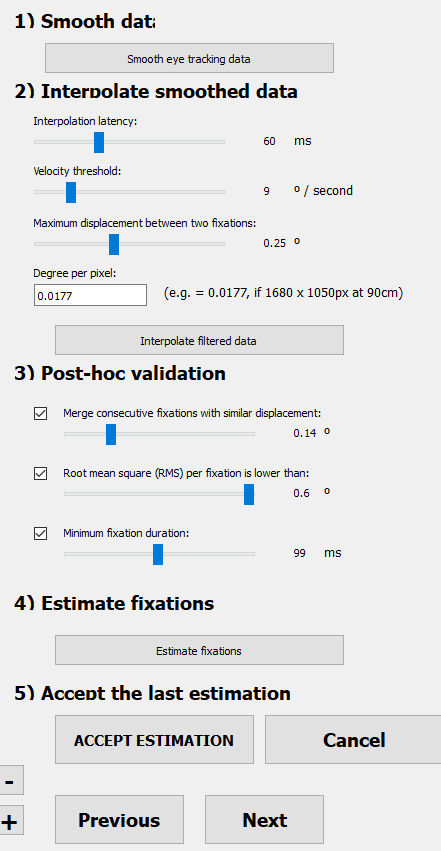

It also generates heatmap. However, adding image did not work for JPGs, only for PNGs.

Exporting did not work for me.

**Data**: It requires a rough.csv (8 columns) and a segments.csv (3 columns). As files have no headers, it is especially difficult to interpret their content. However, first column of segments.csv looks like an incrementing integer for segment id.

Example of rough.csv
```
1359372500278.000000,0.000000,0.461000,0.577000,0.460000,0.624000,4.037000,4.134000
1359372500286.000000,0.000000,0.464000,0.579000,0.458000,0.623000,4.052000,4.183000
1359372500295.000000,0.000000,0.465000,0.567000,0.467000,0.537000,4.069000,4.082000
```
(tip: TS, LEX, LEY, REX, REY, LED, RED)


Example of segments.csv:
```
1.000000,98015.000000,100424.000000
2.000000,104378.000000,106786.000000
3.000000,110718.000000,113128.000000
4.000000,117025.000000,119433.000000
5.000000,123336.000000,125745.000000
```
(tip, time of different images to display, from-to)


Links:
* [Article](https://pmc.ncbi.nlm.nih.gov/articles/PMC4333362/)
* [Program](https://sourceforge.net/projects/grafixfixationscoder/)
* [Github Repo](https://github.com/krastanov-veselin/grafix)

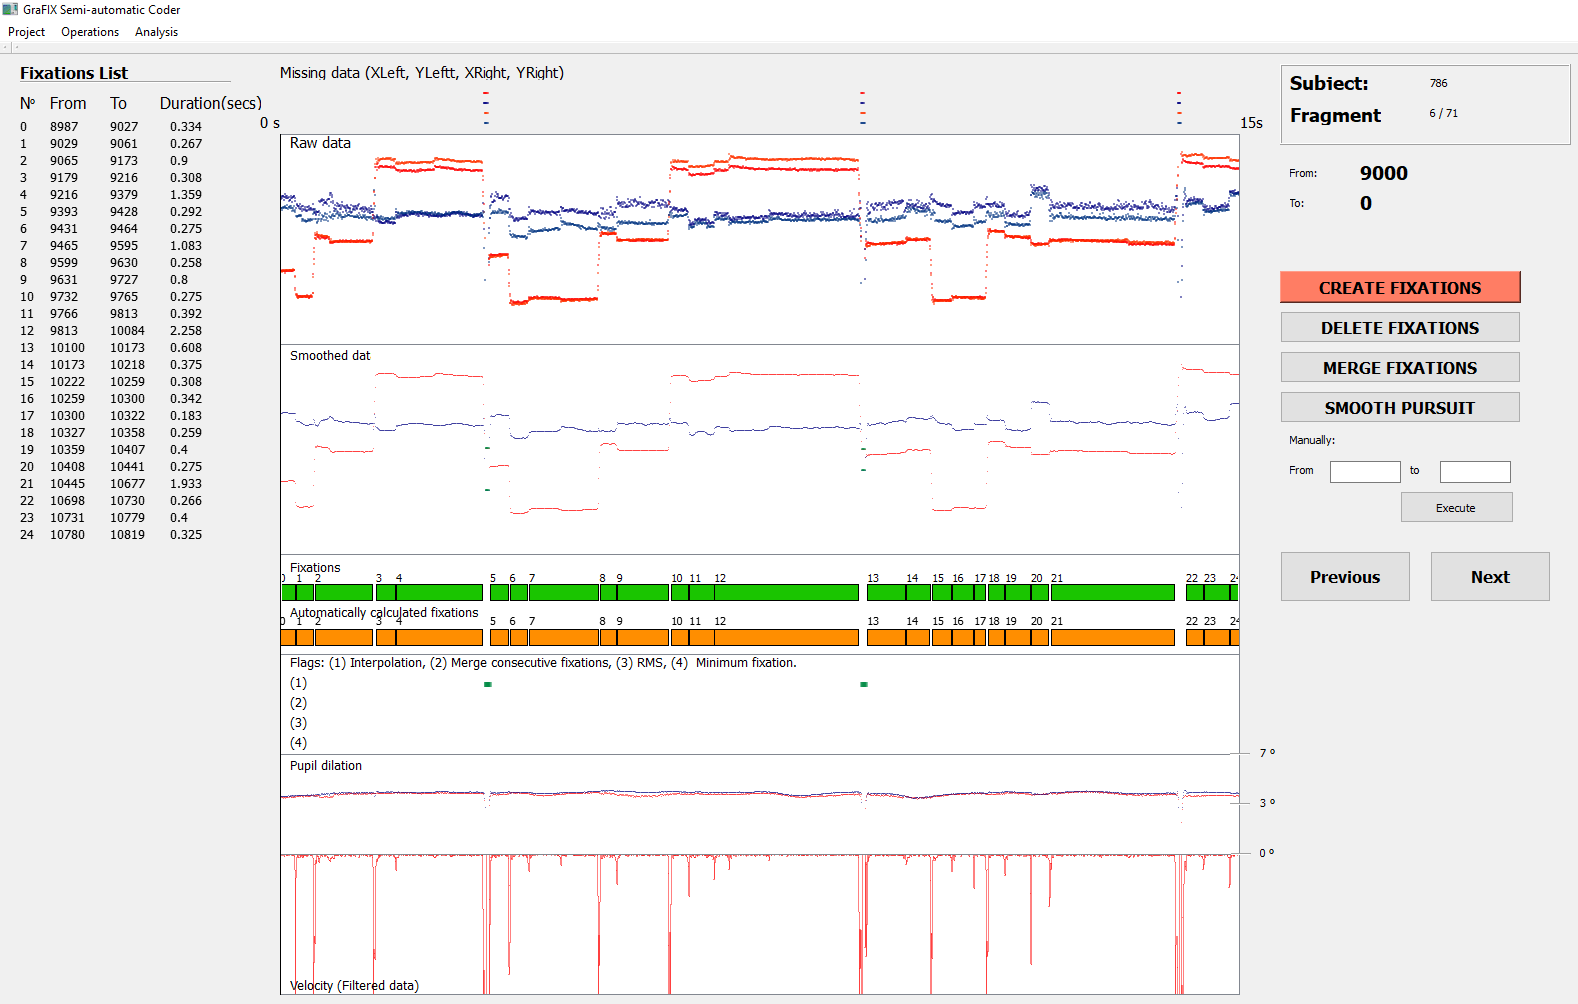

# Tamas Zsolnai's Case

In [ ]:
#

## Conclusions

Detect Reaction Times (RTs) from eye-tracking data. Because the eye-tracker used was "low-speed" (under 200 Hz), they chose a Dispersion-Threshold Identification (I-DT) algorithm.


Firstly, The Core Algorithm was I-DT. The system used a "sliding window" approach to analyze the most recent 100 ms of data (the duration threshold) at any given time.

* Dispersion (D): It calculates how much the gaze "spreads out" within that window.

* Dispersion Threshold (DT): If the spread is smaller than a specific size, the gaze is considered "stable" enough to be a fixation.

Secondly, They identified the "valid" responses.
For the system to register that a participant successfully looked at a target:

* Duration: The fixation had to last at least 100 ms.

* Location (AOI): The center of that fixation had to fall within a square Area of Interest (AOI) around the stimulus.

Result: Once these conditions were met, the trial ended, the stimulus disappeared, and the Reaction Time was recorded.

Links:
* [Article](https://scholar.google.com/citations?hl=en&user=RQ2zA-4AAAAJ&citation_for_view=RQ2zA-4AAAAJ:K3LRdlH-MEoC&view_op=view_citation)

# Other Ideas

I would be happy to create a tool that does such analyses on data.
 * Use the existing models to calculate fixations
 * Compare their results, and try to identify their strengths and weaknesses
 * Optionally, adding some extra features I did not find (examples: averaging blinking data or not, averaging the positions of the 2 eyes or not etc.)
 * My prototype would be a jupyter notebook having interactive UI (see above). Later, I would extend it to accept bulk of files if needed. For request, I can create Desktop application as well.

What I need:
 * Bunch of examples of raw input files
 * Corresponding stimulus
 * Other data that would be used for researches (example: area of interest info)
 * Example refined data to see the expected output

Proposed next steps:
 * Analyze real-world data and its result
 * Try to convert data to be handled by several tools
 * Run the same input in the tools
 * Compare their results, try to identify the reason of differences
 * Make Jupyter notebook that runs several tools using the same input data, and visualize the results.